In [1]:
import numpy as np
import pandas as pd


In [ ]:
df = pd.read_csv("powerplant_data.csv")
df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [3]:
# data is pre-processed
X = df.drop(["PE"],axis = 1)
y = df["PE"]

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 1.convert to tensor 2.tensordataset 3. tensor dataloder

In [6]:
# tensor mai convert jaro
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype = torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype = torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype = torch.float32).view(-1,1) # standard scaler returhs a numpy array and torch.tensor alsop expects a array therefore no error where as we did not scaleed y_train we have to convert it therefore we used this . values and also use of .view(-1,1)
y_test_tensor = torch.tensor(y_test.values,dtype = torch.float32).view(-1 , 1)


In [7]:
# DATA LODER  creates batcjes fot us - yaad karo mini batch os
# data sets - acces tensorws from memeory and loder takes it from datasets

# DATASETS ----> DATALODER

In [8]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor ,y_train_tensor )
test_dataset = TensorDataset(X_test_tensor , y_test_tensor)

In [9]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

# build/define ANN model


In [10]:
class ANN(nn.Module):
    def __init__(self):
        super (ANN, self).__init__()

        # create model
        self.model = nn.Sequential(
            # layer 1
            nn.Linear(X_train.shape[1], 6 ) ,# no of inputs an dnp of outputs
            nn.ReLU(), # activation funtion

            #layer2
            nn.Linear(6,6),
            nn.ReLU(),

            #layer3 - last
            nn.Linear(6,1), # itsself is linear activaion funtion   
        )
    def forward(self,x):
        return self.model(x)

In [11]:
# find the loss funtionn as criteria and optimiser - adam

import torch.optim as optim

model = ANN()

criterion = nn.MSELoss()
optimiser = optim.Adam(model.parameters())

## trian the ANN model

In [12]:
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    # ek epoch mai

    model.train()# training mode

    running_loss = 0.0 # this is for 1 epoch

    for xb,yb in train_loader: # featueres of 1 batch
        
        optimiser.zero_grad() # dont accumulate gradient

        outputs = model(xb) # forward prop
        loss = criterion(outputs, yb) # cal loss
        loss.backward() # back prop....compute gradients
        optimiser.step() # params update

        running_loss += loss.item() # loss is a tensor => py float

    # we will get out trainning loss/epoch
    epoch_train_loss = running_loss / len(train_loader) # avg loss per batch
    train_losses.append(epoch_train_loss)

    #validation - epoch wale loop mai hi oga
    model.eval()

    running_val_loss = 0.0
    
    with torch.no_grad():
        for xb,yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_val_loss += loss
            
    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    # per epoch print karo
    # print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt")
print("traininf done")

traininf done


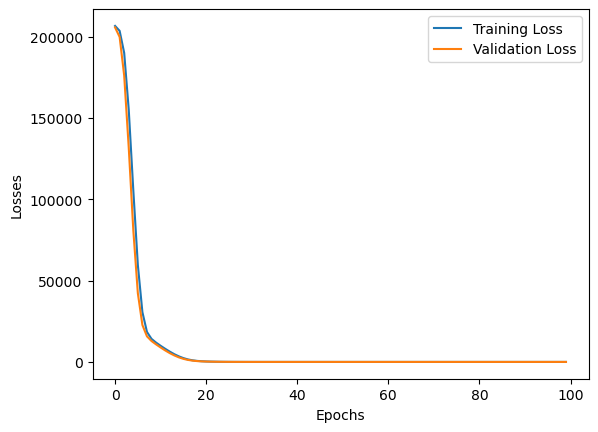

In [13]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

# load best model and evaluation


In [14]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [15]:
# Evaluation

model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = criterion(train_preds, y_train_tensor)
    test_mse_loss = criterion(test_preds, y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())

Training MSE: 20.301193237304688
Testing MSE: 18.565326690673828


In [16]:
from sklearn.metrics import r2_score

print("r^2 score =", r2_score(y_test, test_preds))

r^2 score = 0.9351189745040455


In [17]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,434.796906,433.27
1,436.290375,438.16
2,461.440704,458.42
3,476.541077,480.82
4,434.998657,441.41
...,...,...
1909,451.032379,456.70
1910,431.009552,438.04
1911,467.653534,467.80
1912,430.410431,437.14
